In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
reg  = pd.read_csv('anonymisedData/studentRegistration.csv')
info = pd.read_csv('anonymisedData/studentInfo.csv')
vle  = pd.read_csv('anonymisedData/vle.csv')
course = pd.read_csv('anonymisedData/courses.csv')

In [3]:
svle = pd.read_csv('anonymisedData/studentVle.csv')

In [4]:
info=info.merge(reg,on=["id_student","code_module","code_presentation"])

In [5]:
svle['week'] = (svle['date'] // 7)+1

In [6]:
for w in [1, 2, 3]:
    wk = (svle[svle['week'] == w].groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().rename(f'clicks_week{w}'))
    info = info.merge(wk, on=['id_student', 'code_module', 'code_presentation'], how='left')
    info[f'clicks_week{w}'] = info[f'clicks_week{w}'].fillna(0).astype(int)

In [7]:
info['click_trend'] = info['clicks_week3'] - info['clicks_week1']

In [8]:
info=info.merge(course,  on=['code_module','code_presentation'], how='left')

In [9]:
last_click = svle.groupby(['id_student', 'code_module', 'code_presentation'])['date'].max().rename('last_click_day')
info = info.merge(last_click, on=['id_student', 'code_module', 'code_presentation'], how='left')

In [10]:
info['days_since_last_click'] = info['module_presentation_length']-info['last_click_day']

In [11]:
unique_res = svle.groupby(['id_student', 'code_module', 'code_presentation'])['id_site'].nunique().rename('unique_resources')
info = info.merge(unique_res, on=['id_student', 'code_module', 'code_presentation'], how='left')
info['unique_resources'] = info['unique_resources'].fillna(0).astype(int)

In [12]:
info['days_since_last_click']=info['days_since_last_click'].fillna(info['module_presentation_length']).astype(int)

In [13]:
info['registered_late'] = (info['date_registration'] > 0).astype(int)

In [14]:
info.drop(columns=['date_registration', 'date_unregistration'], inplace=True)

In [15]:
eduo = {'No Formal quals': 0, 'Lower Than A Level': 1,
             'A Level or Equivalent': 2, 'HE Qualification': 3,
             'Post Graduate Qualification': 4}
info['education_enc'] = info['highest_education'].map(eduo)

In [16]:
ageo = {'0-35':1,'35-55':2,'55<=':3}
info['age_enc'] = info['age_band'].map(ageo).astype(int)

In [17]:
reso = {'Pass': 0, 'Distinction': 0, 'Fail': 1, 'Withdrawn': 1}
info['at_risk'] = info['final_result'].map(reso)

In [18]:
imdo = {
    '0-10%':0, '10-20':1, '20-30%':2, '30-40%':3, '40-50%':4,
    '50-60%':5, '60-70%':6, '70-80%':7, '80-90%':8, '90-100%':9
}

info["imd_band_enc"] = info["imd_band"].map(imdo)

In [19]:
TrueData = info[(info["code_module"] == "BBB") &(info["code_presentation"] == "2014J")]

In [20]:
info = info[~(
    (info["code_module"] == "BBB") &
    (info["code_presentation"] == "2014J")
)]

In [21]:
info["imd_band_enc"] = (
    info["imd_band_enc"]
    .fillna(
        info.groupby("region")["imd_band_enc"]#["region", "final_result"]
            .transform("median")
    )
)

In [22]:
info["imd_band_enc"] = info["imd_band_enc"].round().astype(int)

In [23]:
TrueData["imd_band_enc"] = (
    TrueData["imd_band_enc"]
    .fillna(
        TrueData.groupby("region")["imd_band_enc"]
            .transform("median")
    )
)

In [24]:
TrueData["imd_band_enc"] = TrueData["imd_band_enc"].round().astype(int)

In [25]:
engineered= info[["gender","region","num_of_prev_attempts","studied_credits",
                  "disability","clicks_week1","clicks_week2","clicks_week3",
                  "click_trend","module_presentation_length",
                  "days_since_last_click","unique_resources","registered_late",
                  "imd_band_enc","education_enc","age_enc",
                  "at_risk"]]

In [26]:
engineered2= TrueData[["gender","region","num_of_prev_attempts","studied_credits",
                  "disability","clicks_week1","clicks_week2","clicks_week3",
                  "click_trend","module_presentation_length",
                  "days_since_last_click","unique_resources","registered_late",
                  "imd_band_enc","education_enc","age_enc",
                  "at_risk"]]

In [27]:
e2 = pd.get_dummies(engineered,dtype=int)

In [28]:
f2=pd.get_dummies(engineered2,dtype=int)

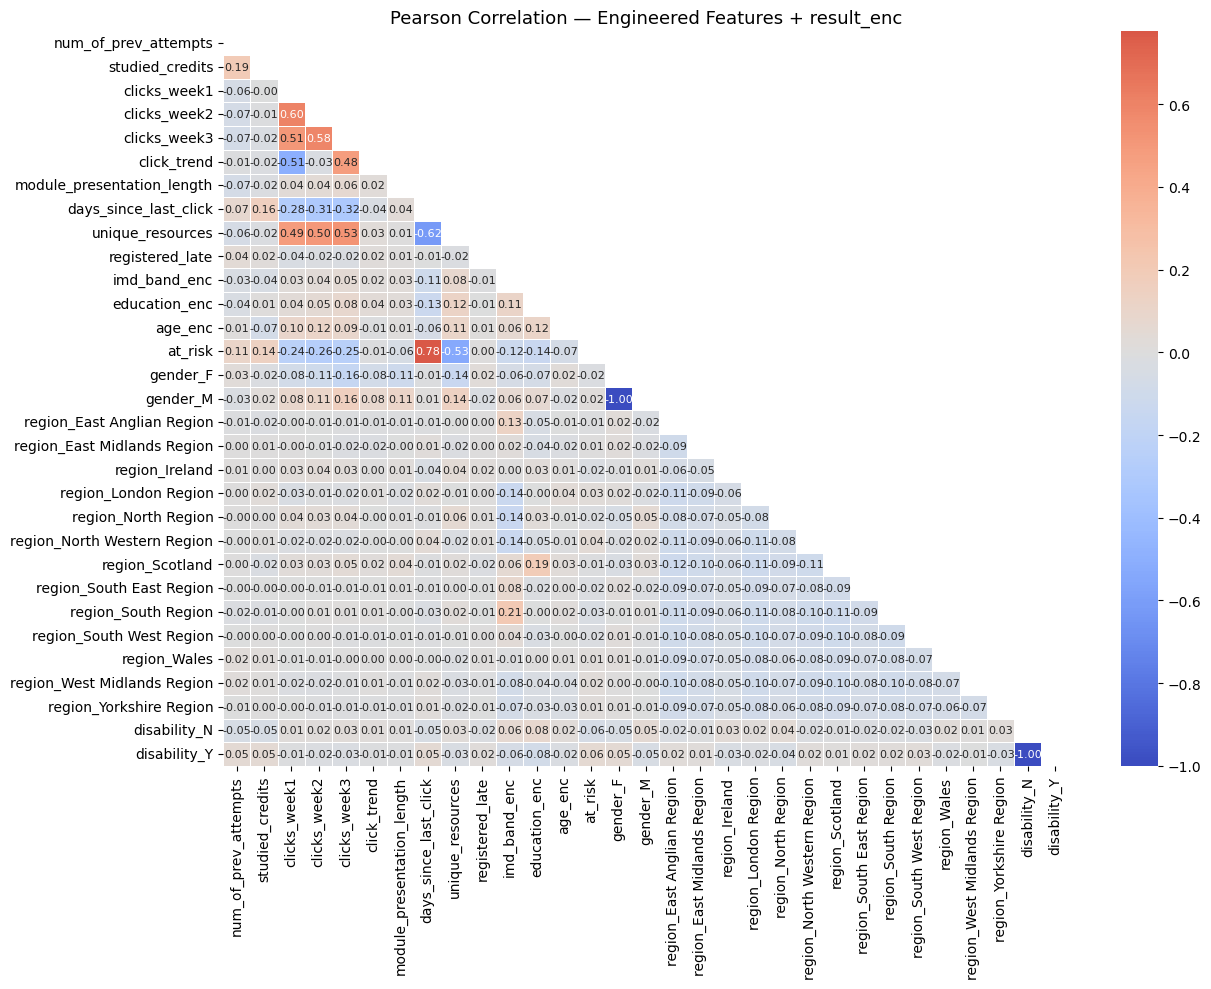

In [29]:
corr_df = e2.corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation — Engineered Features + result_enc', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
e2.to_csv('Training.csv', index=False)

In [31]:
#tests= f2.drop(columns='at_risk')

In [32]:
f2.to_csv('Testing.csv', index=False)